# CarDekho Kolkata Used Cars — Cleaning, Preprocessing & EDA

Takes the raw scraped CSV and produces a clean, feature-engineered, ML-ready dataset.

**Pipeline**: dedupe → drop unneeded columns → resolve missing values → parse/engineer features → geocode locations → EDA → final encoding → export.

Install once if needed: `pip install pandas numpy matplotlib seaborn geopy --break-system-packages`

In [1]:
import re
import time
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

CURRENT_YEAR = datetime.now().year

## 1. Load & first look

In [2]:
df = pd.read_csv("cardekho_kolkata_scraped_data.csv")
print("Shape:", df.shape)
df.head()

Shape: (1088, 15)


,Title,Link,Price,Year,KM Driven,Fuel Type,Transmission,Location,AI Highlights,Price (detail page),KM Driven (detail page),EMI,Fuel Type (detail page),Transmission (detail page),Owner
0,MG Hector Sharp DCT,https://www.cardekho.com/used-car-details/used...,8.65L,2019,"65,000 kms",Petrol,Automatic,"Ballygunge, Kolkata","AI Expert\nGREAT PRICE\n1st owner, 65k km — ow...",₹8.65 Lakh,"65,000 km","EMI from ₹21,470/mo",Petrol,Automatic,1st Owner
1,Maruti Suzuki Alto K10 VXI,https://www.cardekho.com/used-car-details/used...,2.25L,2017,"35,471 kms",Petrol,Manual,"E.k.t, Kolkata","AI Expert\nGREAT PRICE\n3 owners, 35k km — pap...",₹2.25 Lakh,"35,471 km","EMI from ₹6,975/mo",Petrol,Manual,3rd Owner
2,Honda WR-V i-VTEC VX,https://www.cardekho.com/used-car-details/used...,5.91L,2022,"50,467 kms",Petrol,Manual,"Airport Po, Kolkata","AI Expert\nGREAT PRICE\n1st owner, 50k km — do...",₹5.91 Lakh,"50,467 km","EMI from ₹14,669/mo",Petrol,Manual,1st Owner
3,Maruti Suzuki Swift Dzire VXI,https://www.cardekho.com/used-car-details/used...,2.77L,2013,"45,046 kms",Petrol,Manual,"Airport Po, Kolkata","AI Expert\nGREAT PRICE\n1st owner, 45k km — ow...",₹2.77 Lakh,"45,046 km",NaN,Petrol,Manual,1st Owner
4,Hyundai Verna SX,https://www.cardekho.com/used-car-details/used...,7.99L,2021,"22,000 kms",Petrol,Manual,"Bhowanipore, Kolkata","AI Expert\nGREAT PRICE\n1st owner, 22k km — hi...",₹7.99 Lakh,"22,000 km\nBelow avg","EMI from ₹19,835/mo",Petrol,Manual,1st Owner


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1088 entries, 0 to 1087
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Title                       1088 non-null   str  
 1   Link                        1088 non-null   str  
 2   Price                       1088 non-null   str  
 3   Year                        1088 non-null   int64
 4   KM Driven                   1088 non-null   str  
 5   Fuel Type                   1008 non-null   str  
 6   Transmission                1008 non-null   str  
 7   Location                    1008 non-null   str  
 8   AI Highlights               960 non-null    str  
 9   Price (detail page)         1087 non-null   str  
 10  KM Driven (detail page)     1087 non-null   str  
 11  EMI                         891 non-null    str  
 12  Fuel Type (detail page)     1087 non-null   str  
 13  Transmission (detail page)  1087 non-null   str  
 14  Owner              

## 2. Deduplicate

Dedupe on `Link` rather than full-row matching — it's the one column guaranteed to uniquely
identify a listing, even if two different ads happen to share identical text elsewhere.

In [4]:
before = len(df)
df = df.drop_duplicates(subset="Link").reset_index(drop=True)
after = len(df)
print(f"Dropped {before - after} duplicate rows ({before} -> {after})")

Dropped 473 duplicate rows (1088 -> 615)


## 3. Missing values — overview

Check what's missing before deciding how to handle each column.

In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_summary = pd.DataFrame({"missing": missing, "pct": missing_pct})
missing_summary[missing_summary["missing"] > 0].sort_values("pct", ascending=False)

,missing,pct
EMI,93,15.1
AI Highlights,17,2.8
Fuel Type,11,1.8
Location,11,1.8
Transmission,11,1.8


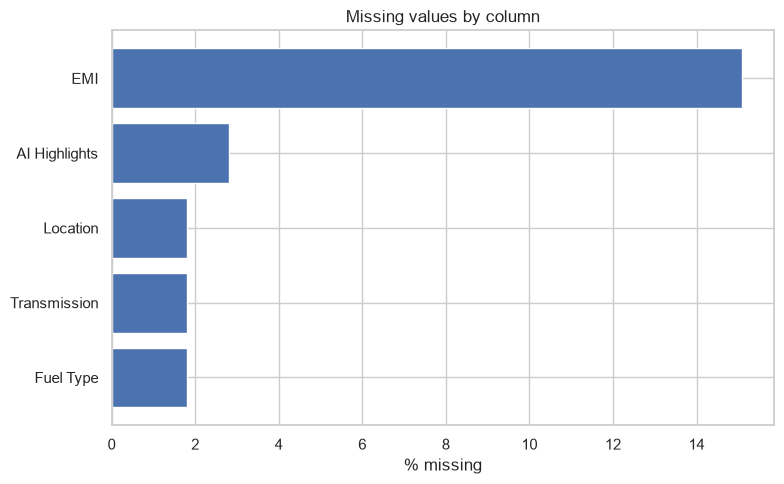

In [6]:
plt.figure(figsize=(8, 5))
ms = missing_summary[missing_summary["missing"] > 0].sort_values("pct")
plt.barh(ms.index, ms["pct"], color="#4C72B0")
plt.xlabel("% missing")
plt.title("Missing values by column")
plt.tight_layout()
plt.show()

## 4. Drop columns we don't need

- `AI Highlights` — free-text marketing blurb, not using it for the model.
- `Price (detail page)` / `KM Driven (detail page)` — these were only a scraping fallback; the
  main `Price` / `KM Driven` columns are already complete, so the fallback columns are redundant.

In [7]:
df = df.drop(columns=["AI Highlights", "Price (detail page)", "KM Driven (detail page)"])
df.shape

(615, 12)

## 5. Fill Fuel Type / Transmission from their detail-page fallback

Both have only 13 missing on the listing-card version, and the detail-page version is
essentially complete (1 missing) — so instead of dropping rows, coalesce the two, then drop
the now-redundant detail-page columns.

In [8]:
df["Fuel Type"] = df["Fuel Type"].fillna(df["Fuel Type (detail page)"])
df["Transmission"] = df["Transmission"].fillna(df["Transmission (detail page)"])

df = df.drop(columns=["Fuel Type (detail page)", "Transmission (detail page)"])

print("Fuel Type missing after fill:", df["Fuel Type"].isna().sum())
print("Transmission missing after fill:", df["Transmission"].isna().sum())

Fuel Type missing after fill: 0
Transmission missing after fill: 0


## 6. Location — fill missing with mode

Only 13 missing (~1-2%) — filling with the most common locality is a reasonable default at this ratio.

In [9]:
location_mode = df["Location"].mode()[0]
print("Mode location:", location_mode)
df["Location"] = df["Location"].fillna(location_mode)
df["Location"].isna().sum()

Mode location: Airport Po, Kolkata


np.int64(0)

## 7. Drop the last few negligible-missing rows

`Owner` has 1 missing value (<0.2% of the data) — at this ratio, dropping the row is
simpler and safer than inventing a value for a categorical field with no natural "default".

In [10]:
df = df.dropna(subset=["Owner"]).reset_index(drop=True)
df.isna().sum()[df.isna().sum() > 0]

EMI    93
dtype: int64

## 8. Feature engineering — parse raw text fields into numeric features

- `Price` (`"8.65L"` / `"1.2Cr"`) → `Price_INR`
- `KM Driven` (`"65,000 kms"`) → `KM_Driven` (int)
- `Year` → `Car_Age` (more model-friendly than a raw year)
- `Owner` (`"1st Owner"`) → `Owner_Number` (ordinal int)
- `Title` → `Brand` (+ `Model` for reference)

In [11]:
def parse_price(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    match = re.match(r"([\d.]+)\s*(L|Cr|K)", val, re.IGNORECASE)
    if not match:
        return np.nan
    number, unit = match.groups()
    number = float(number)
    unit = unit.upper()
    multiplier = {"K": 1_000, "L": 100_000, "CR": 10_000_000}[unit]
    return number * multiplier

df["Price_INR"] = df["Price"].apply(parse_price)
print("Unparsed prices:", df["Price_INR"].isna().sum())
df[["Price", "Price_INR"]].head()

Unparsed prices: 0


,Price,Price_INR
0,8.65L,865000.0
1,2.25L,225000.0
2,5.91L,591000.0
3,2.77L,277000.0
4,7.99L,799000.0


In [12]:
df["KM_Driven"] = (
    df["KM Driven"]
    .str.replace(",", "", regex=False)
    .str.extract(r"(\d+)")[0]
    .astype(float)
)
df[["KM Driven", "KM_Driven"]].head()

,KM Driven,KM_Driven
0,"65,000 kms",65000.0
1,"35,471 kms",35471.0
2,"50,467 kms",50467.0
3,"45,046 kms",45046.0
4,"22,000 kms",22000.0


In [13]:
df["Car_Age"] = CURRENT_YEAR - df["Year"]
df[["Year", "Car_Age"]].head()

,Year,Car_Age
0,2019,7
1,2017,9
2,2022,4
3,2013,13
4,2021,5


In [14]:
df["Owner_Number"] = df["Owner"].str.extract(r"(\d+)").astype(float)
df[["Owner", "Owner_Number"]].drop_duplicates().sort_values("Owner_Number")

,Owner,Owner_Number
36,0th Owner,0.0
0,1st Owner,1.0
10,2nd Owner,2.0
1,3rd Owner,3.0
131,4th Owner,4.0


In [15]:
# "Maruti Suzuki" is a common two-word brand name in this market - handle it explicitly,
# otherwise take the first word of the title as the brand.
MULTI_WORD_BRANDS = ["Maruti Suzuki", "Mercedes-Benz", "Land Rover", "Mahindra & Mahindra"]

def split_brand_model(title):
    for brand in MULTI_WORD_BRANDS:
        if title.startswith(brand):
            return brand, title[len(brand):].strip()
    parts = title.split(maxsplit=1)
    if len(parts) == 2:
        return parts[0], parts[1]
    return parts[0], ""

brand_model = df["Title"].apply(split_brand_model)
df["Brand"] = brand_model.apply(lambda x: x[0])
df["Model"] = brand_model.apply(lambda x: x[1])
df[["Title", "Brand", "Model"]].head(10)

,Title,Brand,Model
0,MG Hector Sharp DCT,MG,Hector Sharp DCT
1,Maruti Suzuki Alto K10 VXI,Maruti Suzuki,Alto K10 VXI
2,Honda WR-V i-VTEC VX,Honda,WR-V i-VTEC VX
3,Maruti Suzuki Swift Dzire VXI,Maruti Suzuki,Swift Dzire VXI
4,Hyundai Verna SX,Hyundai,Verna SX
5,Hyundai Creta SX (O) Turbo DCT,Hyundai,Creta SX (O) Turbo DCT
6,Skoda Slavia 1.0 TSI Style,Skoda,Slavia 1.0 TSI Style
7,Toyota Hyryder V AT,Toyota,Hyryder V AT
8,Maruti Suzuki Ciaz Zeta BSVI,Maruti Suzuki,Ciaz Zeta BSVI
9,Volkswagen Polo 1.2 MPI Comfortline,Volkswagen,Polo 1.2 MPI Comfortline


## 9. EMI — parse, inspect distribution, then decide fill strategy

**Important caveat before filling anything**: EMI is *derived from* Price by CarDekho's own loan
calculator, not an independent attribute of the car. If this notebook's output feeds a
price-prediction model later, EMI should be **excluded from the model's feature set** — including
it would let the model shortcut to "predict EMI × constant", which isn't genuine learning from car
attributes and won't generalize. It's kept here purely for EDA (e.g. sanity-checking it against Price).

In [16]:
df["EMI_INR"] = (
    df["EMI"]
    .str.extract(r"\u20b9([\d,]+)")[0]
    .str.replace(",", "", regex=False)
    .astype(float)
)
df["EMI_INR"].describe()

count       522.000000
mean      24940.668582
std       25219.918075
min        4890.000000
25%       12124.500000
50%       18198.000000
75%       27808.500000
max      243238.000000
Name: EMI_INR, dtype: float64

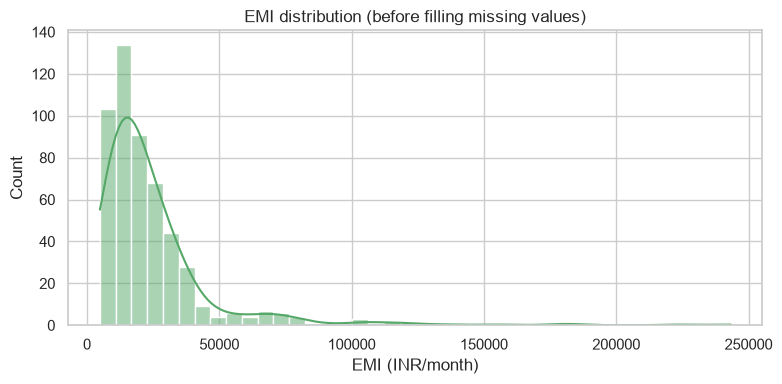

In [17]:
plt.figure(figsize=(8, 4))
sns.histplot(df["EMI_INR"].dropna(), bins=40, kde=True, color="#55A868")
plt.title("EMI distribution (before filling missing values)")
plt.xlabel("EMI (INR/month)")
plt.tight_layout()
plt.show()

The distribution is right-skewed (a long tail of high-EMI/high-price cars pulls the mean up) —
median is the safer fill for a skewed distribution since it's not dragged by that tail.

In [18]:
emi_median = df["EMI_INR"].median()
print("Median EMI:", emi_median)
df["EMI_INR"] = df["EMI_INR"].fillna(emi_median)
df["EMI_INR"].isna().sum()

Median EMI: 18198.0


np.int64(0)

## 10. Location → latitude/longitude

First, see how many *unique* localities we're actually geocoding — much cheaper than geocoding
every row, since many cars share the same locality.

In [19]:
unique_locations = df["Location"].unique()
print(f"{len(unique_locations)} unique locations out of {len(df)} rows")
sorted(unique_locations)

94 unique locations out of 615 rows


['A.J.C.Bose Road, Kolkata',
 'Airport Po, Kolkata',
 'Airport, Kolkata',
 'Alipore Mint Colony, Alipore, Kolkata',
 'Alipore, Kolkata',
 'Anandapally, Kamalgachhi More, Kolkata',
 'Ashoke Road, Ashok Trust, Raipur, Ganguly Bagan, Kolkata',
 'Asylum Lane, Kolkata',
 'Aurobindo Basu Nagar, Sarsuna, Kolkata',
 'Baghbazar, Kolkata',
 'Ballygunge RS, Kolkata',
 'Ballygunge Rs, Kolkata',
 'Ballygunge, Kolkata',
 'Barabazar, Kolkata',
 'Baranagar, Kolkata',
 'Behala, Kolkata',
 'Beleghata, Kolkata',
 'Belgachia, Kolkata',
 'Bhawanipore, Kolkata',
 'Bhowanipore, Kolkata',
 'Bonhooghly, Kolkata',
 'Canal Circular Road, Phool Bagan, Kankurgachi, Kolkata',
 'Central Park, Bidhannagar, Kolkata',
 'Cornelia Sorabji Road, Maidan, B.B.D. Bagh, Kolkata',
 'Cossipore, Kolkata',
 'Dakshindari Road, Ghoshpara, Lake Town, Kolkata',
 'Desh Bandhu Nagar, Kolkata',
 'Dum Dum, Kolkata',
 'Dumdum Road, Kolkata',
 'Dumdum, Kolkata',
 'E.K.T, Kolkata',
 'E.k.t, Kolkata',
 'Elliot Road, Kolkata',
 'Entally, Kolk

In [20]:
geolocator = Nominatim(user_agent="cardekho_kolkata_project")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)  # Nominatim's usage policy: max 1 req/sec

location_coords = {}
for loc in unique_locations:
    query = f"{loc}, India"
    try:
        result = geocode(query)
        if result:
            location_coords[loc] = (result.latitude, result.longitude)
        else:
            location_coords[loc] = (np.nan, np.nan)
    except Exception as e:
        print(f"Failed to geocode '{loc}': {e}")
        location_coords[loc] = (np.nan, np.nan)

print(f"Geocoded {sum(1 for v in location_coords.values() if not pd.isna(v[0]))} / {len(unique_locations)} locations")

RateLimiter caught an error, retrying (0/2 tries). Called with (*('University, Kolkata, India',), **{}).
Traceback (most recent call last):
  File "C:\Users\SPANDAN CHATTERJEE\Desktop\used_car_scraper_kolkata\cars\Lib\site-packages\urllib3\connection.py", line 204, in _new_conn
    sock = connection.create_connection(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\SPANDAN CHATTERJEE\Desktop\used_car_scraper_kolkata\cars\Lib\site-packages\urllib3\util\connection.py", line 85, in create_connection
    raise err
  File "C:\Users\SPANDAN CHATTERJEE\Desktop\used_car_scraper_kolkata\cars\Lib\site-packages\urllib3\util\connection.py", line 73, in create_connection
    sock.connect(sa)
TimeoutError: timed out

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "C:\Users\SPANDAN CHATTERJEE\Desktop\used_car_scraper_kolkata\cars\Lib\site-packages\urllib3\connectionpool.py", line 788, in urlopen
    response = self._make_reque

Geocoded 55 / 94 locations


In [21]:
df["Latitude"] = df["Location"].map(lambda x: location_coords[x][0])
df["Longitude"] = df["Location"].map(lambda x: location_coords[x][1])

# Fallback: any locality that failed to geocode gets Kolkata's city-center coordinates
# rather than being left null (better than dropping rows over a geocoding hiccup)
KOLKATA_CENTER = (22.5726, 88.3639)
failed = df["Latitude"].isna()
print(f"{failed.sum()} rows falling back to Kolkata city-center coordinates")
df.loc[failed, "Latitude"] = KOLKATA_CENTER[0]
df.loc[failed, "Longitude"] = KOLKATA_CENTER[1]

df[["Location", "Latitude", "Longitude"]].drop_duplicates().head(10)

196 rows falling back to Kolkata city-center coordinates


,Location,Latitude,Longitude
0,"Ballygunge, Kolkata",22.528034,88.365908
1,"E.k.t, Kolkata",22.572600,88.363900
2,"Airport Po, Kolkata",22.572600,88.363900
4,"Bhowanipore, Kolkata",22.532584,88.345443
7,"University, Kolkata",22.982232,88.439166
8,"Regent Park, Kolkata",22.488447,88.356013
9,"Kalighat, Kolkata",22.515331,88.347705
10,"Gobinda Khatick Road, Kolkata",22.560688,88.381972
11,"Jodhpur Park, Kolkata",22.505606,88.363674
17,"Garia Bt, Kolkata",22.456525,88.386511


## 11. Final missing-value check

Should be clean now except the columns we've deliberately excluded from feature engineering.

In [22]:
df.isna().sum()[df.isna().sum() > 0]

EMI    93
dtype: int64

## 12. EDA

Each cell below covers one feature (or one closely related pair) against the target, `Price_INR`.

### Target variable: Price

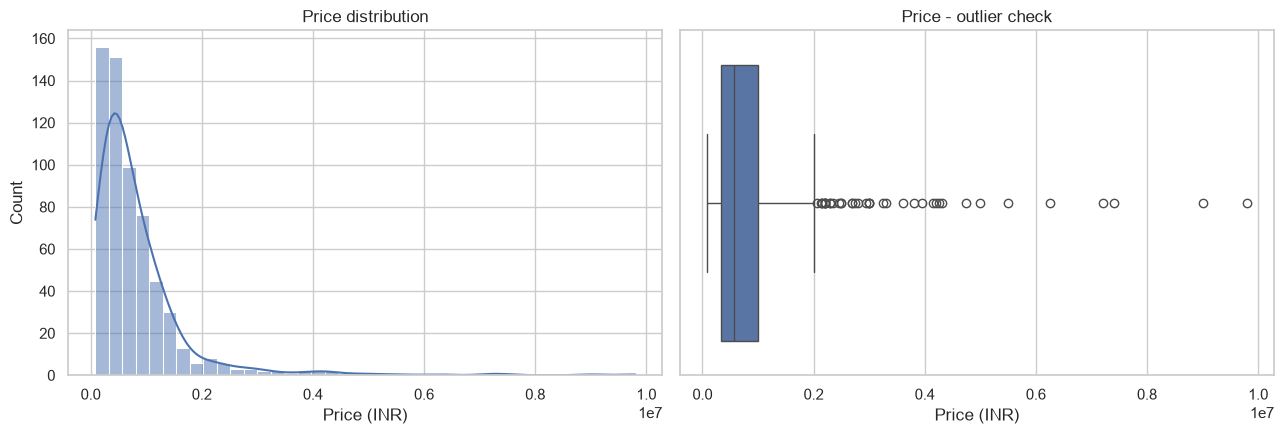

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["Price_INR"], bins=40, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Price distribution")
axes[0].set_xlabel("Price (INR)")

sns.boxplot(x=df["Price_INR"], ax=axes[1], color="#4C72B0")
axes[1].set_title("Price - outlier check")
axes[1].set_xlabel("Price (INR)")

plt.tight_layout()
plt.show()

### Price vs. Car Age & KM Driven (continuous relationships)

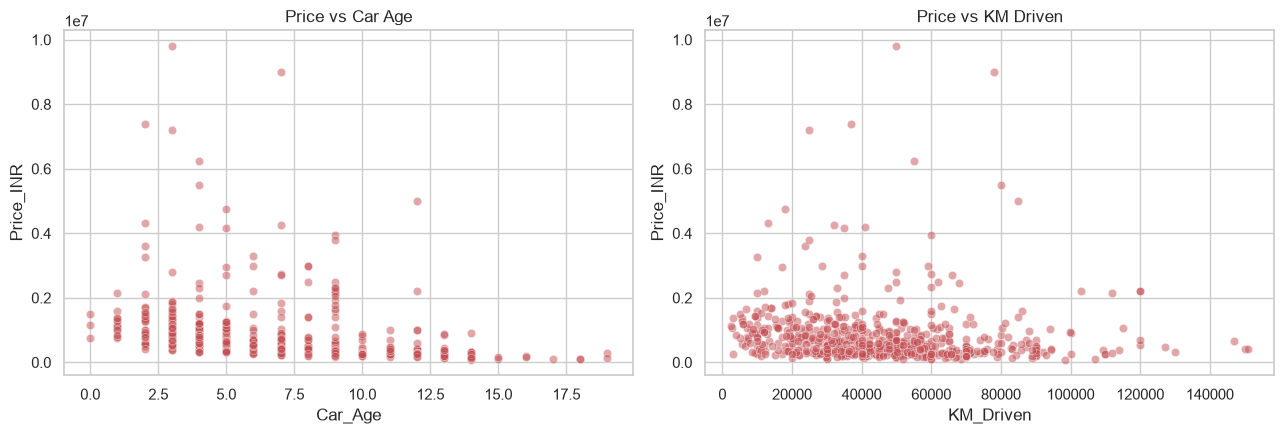

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.scatterplot(data=df, x="Car_Age", y="Price_INR", alpha=0.5, ax=axes[0], color="#C44E52")
axes[0].set_title("Price vs Car Age")

sns.scatterplot(data=df, x="KM_Driven", y="Price_INR", alpha=0.5, ax=axes[1], color="#C44E52")
axes[1].set_title("Price vs KM Driven")

plt.tight_layout()
plt.show()

### Fuel Type

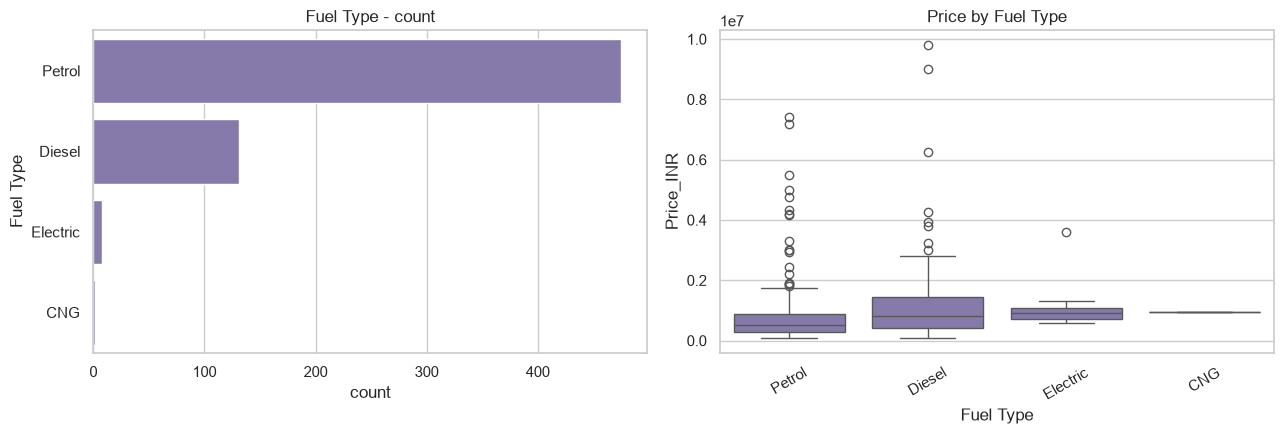

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.countplot(data=df, y="Fuel Type", order=df["Fuel Type"].value_counts().index, ax=axes[0], color="#8172B2")
axes[0].set_title("Fuel Type - count")

sns.boxplot(data=df, x="Fuel Type", y="Price_INR", order=df["Fuel Type"].value_counts().index, ax=axes[1], color="#8172B2")
axes[1].set_title("Price by Fuel Type")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### Transmission

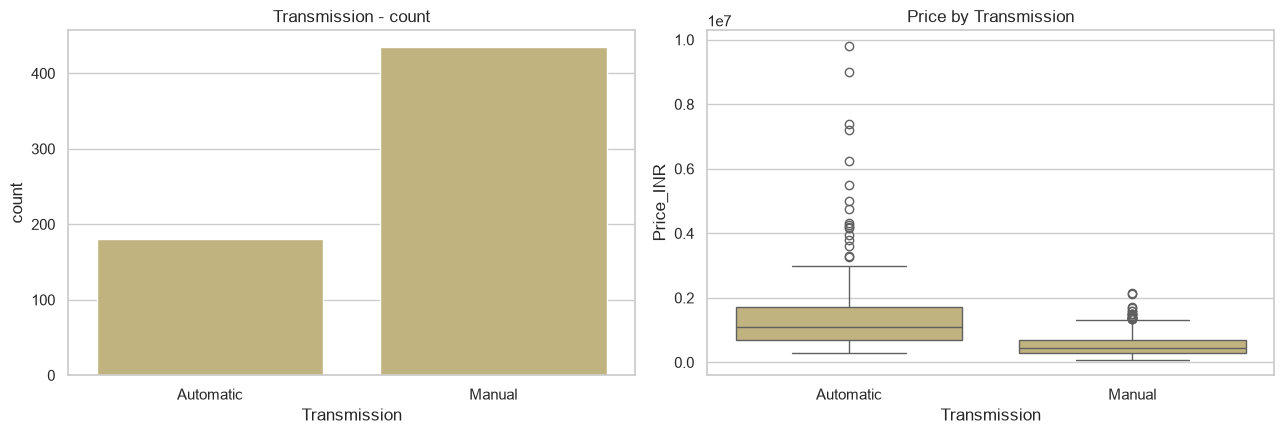

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.countplot(data=df, x="Transmission", ax=axes[0], color="#CCB974")
axes[0].set_title("Transmission - count")

sns.boxplot(data=df, x="Transmission", y="Price_INR", ax=axes[1], color="#CCB974")
axes[1].set_title("Price by Transmission")

plt.tight_layout()
plt.show()

### Ownership

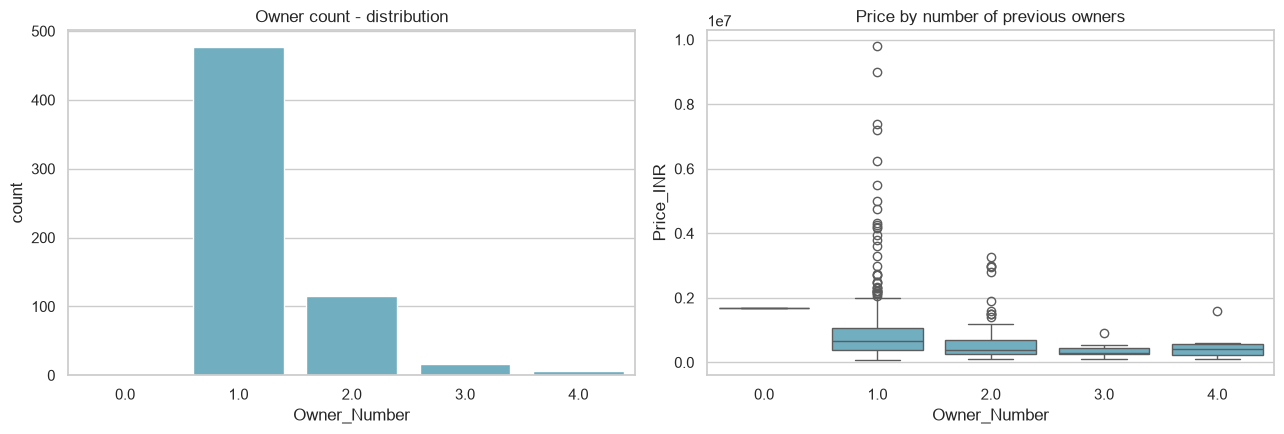

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.countplot(data=df, x="Owner_Number", ax=axes[0], color="#64B5CD")
axes[0].set_title("Owner count - distribution")

sns.boxplot(data=df, x="Owner_Number", y="Price_INR", ax=axes[1], color="#64B5CD")
axes[1].set_title("Price by number of previous owners")

plt.tight_layout()
plt.show()

### Brand (top 12 by listing count)

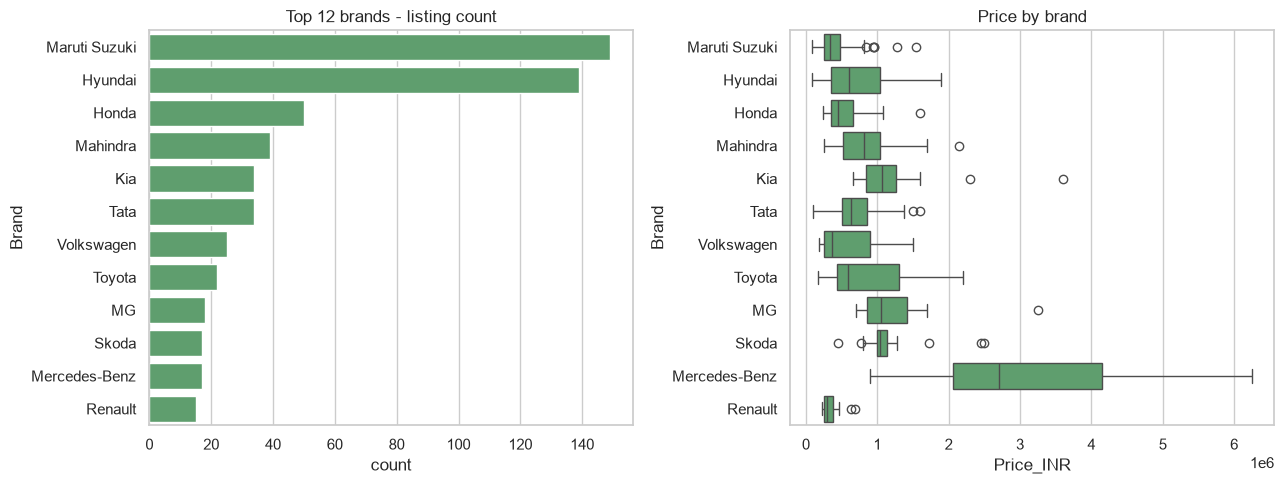

In [28]:
top_brands = df["Brand"].value_counts().head(12).index
df_top_brands = df[df["Brand"].isin(top_brands)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df_top_brands, y="Brand", order=top_brands, ax=axes[0], color="#55A868")
axes[0].set_title("Top 12 brands - listing count")

sns.boxplot(data=df_top_brands, x="Price_INR", y="Brand", order=top_brands, ax=axes[1], color="#55A868")
axes[1].set_title("Price by brand")

plt.tight_layout()
plt.show()

### EMI vs Price — sanity check for the leakage concern flagged earlier

Expect a near-perfectly straight line, since EMI is computed directly from Price. This plot is
the visual proof of *why* EMI is excluded from the modeling feature set below.

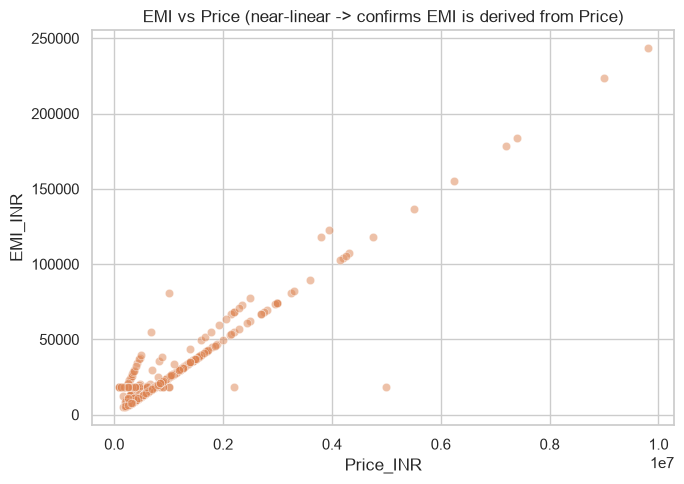

In [29]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Price_INR", y="EMI_INR", alpha=0.5, color="#DD8452")
plt.title("EMI vs Price (near-linear -> confirms EMI is derived from Price)")
plt.tight_layout()
plt.show()

### Geographic spread of listings

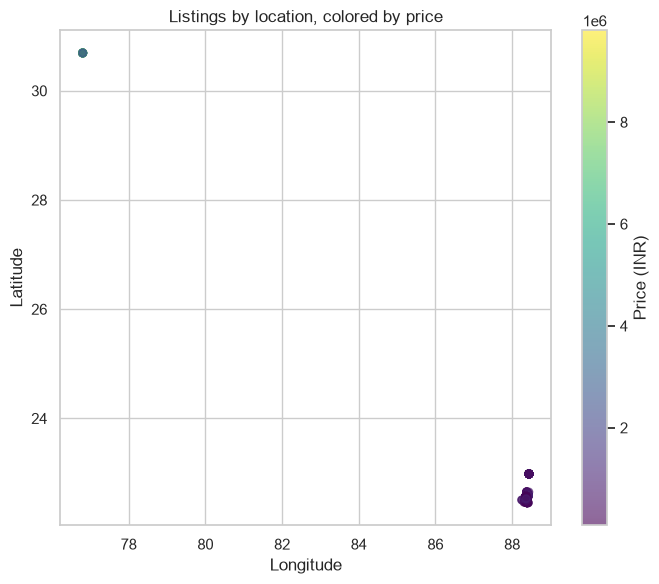

In [30]:
plt.figure(figsize=(7, 6))
sc = plt.scatter(df["Longitude"], df["Latitude"], c=df["Price_INR"], cmap="viridis", alpha=0.6, s=30)
plt.colorbar(sc, label="Price (INR)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Listings by location, colored by price")
plt.tight_layout()
plt.show()

### Correlation between numeric features

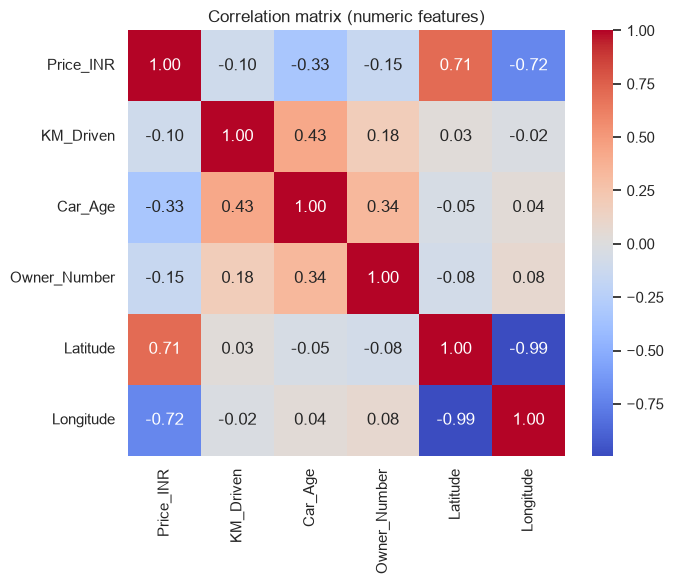

In [31]:
numeric_cols = ["Price_INR", "KM_Driven", "Car_Age", "Owner_Number", "Latitude", "Longitude"]
plt.figure(figsize=(7, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.show()

## 13. Final encoding — make it ML-ready

- One-hot encode `Fuel Type` and `Transmission` (low cardinality).
- `Brand`: many categories — bucket anything outside the top 12 into `"Other"` first, then one-hot,
  to avoid an explosion of near-empty columns.
- Drop raw/text columns no longer needed once their engineered numeric versions exist.
- `EMI_INR` is deliberately **excluded** from the model feature set (see leakage note above) —
  kept in the full dataframe for reference, dropped only from the exported ML-ready file.

In [32]:
df["Brand_grouped"] = df["Brand"].where(df["Brand"].isin(top_brands), "Other")

df_ml = pd.get_dummies(
    df,
    columns=["Fuel Type", "Transmission", "Brand_grouped"],
    prefix=["Fuel", "Trans", "Brand"],
    drop_first=True,
)

# Drop columns not used as model inputs: raw text versions, identifiers, and EMI (leakage)
drop_cols = ["Title", "Link", "Price", "KM Driven", "Year", "Owner", "Location", "EMI", "EMI_INR", "Brand", "Model"]
df_ml = df_ml.drop(columns=drop_cols)

print(df_ml.shape)
df_ml.head()

(615, 22)


,Price_INR,KM_Driven,Car_Age,Owner_Number,Latitude,Longitude,Fuel_Diesel,Fuel_Electric,Fuel_Petrol,Trans_Manual,Brand_Hyundai,Brand_Kia,Brand_MG,Brand_Mahindra,Brand_Maruti Suzuki,Brand_Mercedes-Benz,Brand_Other,Brand_Renault,Brand_Skoda,Brand_Tata,Brand_Toyota,Brand_Volkswagen
0,865000.0,65000.0,7,1.0,22.528034,88.365908,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False
1,225000.0,35471.0,9,3.0,22.572600,88.363900,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False
2,591000.0,50467.0,4,1.0,22.572600,88.363900,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False
3,277000.0,45046.0,13,1.0,22.572600,88.363900,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False
4,799000.0,22000.0,5,1.0,22.532584,88.345443,False,False,True,True,True,False,False,False,False,False,False,False,False,False,False,False


In [33]:
df_ml.to_csv("cardekho_kolkata_ml_ready.csv", index=False)
print("Saved: cardekho_kolkata_ml_ready.csv")

Saved: cardekho_kolkata_ml_ready.csv
